<a href="https://colab.research.google.com/github/madhuraspatil/AIML_Practicle/blob/main/Search_algorithm_On_Robot_Path_Finding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Title: Evaluate the performance of various algorithms (Uninformed, Informed, Local Search and Constraint Satisfaction) of problem solving through Search.

Aim: To evaluate and compare different Artificial Intelligence search algorithms for solving a robot path-finding problem in a grid environment, including Uninformed Search, Informed Search, Local Search, and Constraint Satisfaction/Optimization techniques.

Objective:
1 To implement Uninformed Search algorithms such as BFS, DFS, and UCS for finding a path from the initial state to the goal state.
2 To implement Informed Search algorithms such as Greedy Best-First Search and A* using a heuristic function.
3 To implement Local Search using the Hill Climbing algorithm for finding an efficient path.
4 To apply a Genetic Algorithm for constraint-based path finding and optimization while avoiding obstacles.
5 To compare the algorithms based on path length, number of nodes explored, and execution time.
6 To understand the advantages and limitations of different search strategies in solving the same problem.
7 To determine how the choice of search algorithm affects the efficiency and quality of the robot's path.


Theory: Search Algorithms in Artificial Intelligence

Search algorithms are fundamental techniques in Artificial Intelligence (AI) used to find a sequence of actions or states that leads from an initial state to a desired goal state. A search problem is generally represented using a state space, where each state represents a possible situation and transitions represent possible actions.

Search algorithms can be broadly classified into Uninformed Search, Informed Search, Local Search, and Constraint Satisfaction/Optimization methods.

1. Uninformed Search

Uninformed search algorithms do not have additional information about how close a state is to the goal. They explore the search space using only the problem definition.

Breadth-First Search (BFS): Explores states level by level. It can find the shortest path when all actions have equal cost.
Depth-First Search (DFS): Explores one branch deeply before backtracking. It generally requires less memory but may not find the shortest solution.
Uniform Cost Search (UCS): Expands the state with the lowest cumulative path cost. It is useful when different actions have different costs.
2. Informed Search

Informed search uses additional knowledge, called a heuristic, to guide the search toward the goal.

Greedy Best-First Search: Selects the state that appears closest to the goal according to the heuristic value h(n).
A* Search: Combines the actual cost and estimated cost using:

f(n) = g(n) + h(n)

where g(n) is the cost from the initial state to the current state and h(n) estimates the cost from the current state to the goal.

3. Local Search

Local search algorithms focus on improving the current solution rather than systematically exploring the entire search space.

Hill Climbing: Starts with an initial state and repeatedly moves to a neighboring state with a better evaluation value. It is simple and uses little memory but can get stuck in local maxima, plateaus, or ridges.

4. Constraint Satisfaction and Optimization

A Constraint Satisfaction Problem (CSP) consists of variables, possible values for those variables, and constraints that determine which combinations are valid.

Genetic Algorithm (GA) is an optimization technique inspired by natural evolution. It represents possible solutions as chromosomes and improves them through:

Population initialization
Fitness evaluation
Selection
Crossover
Mutation
Generation of new populations

The process continues for several generations until a satisfactory solution is obtained.

flowchart : 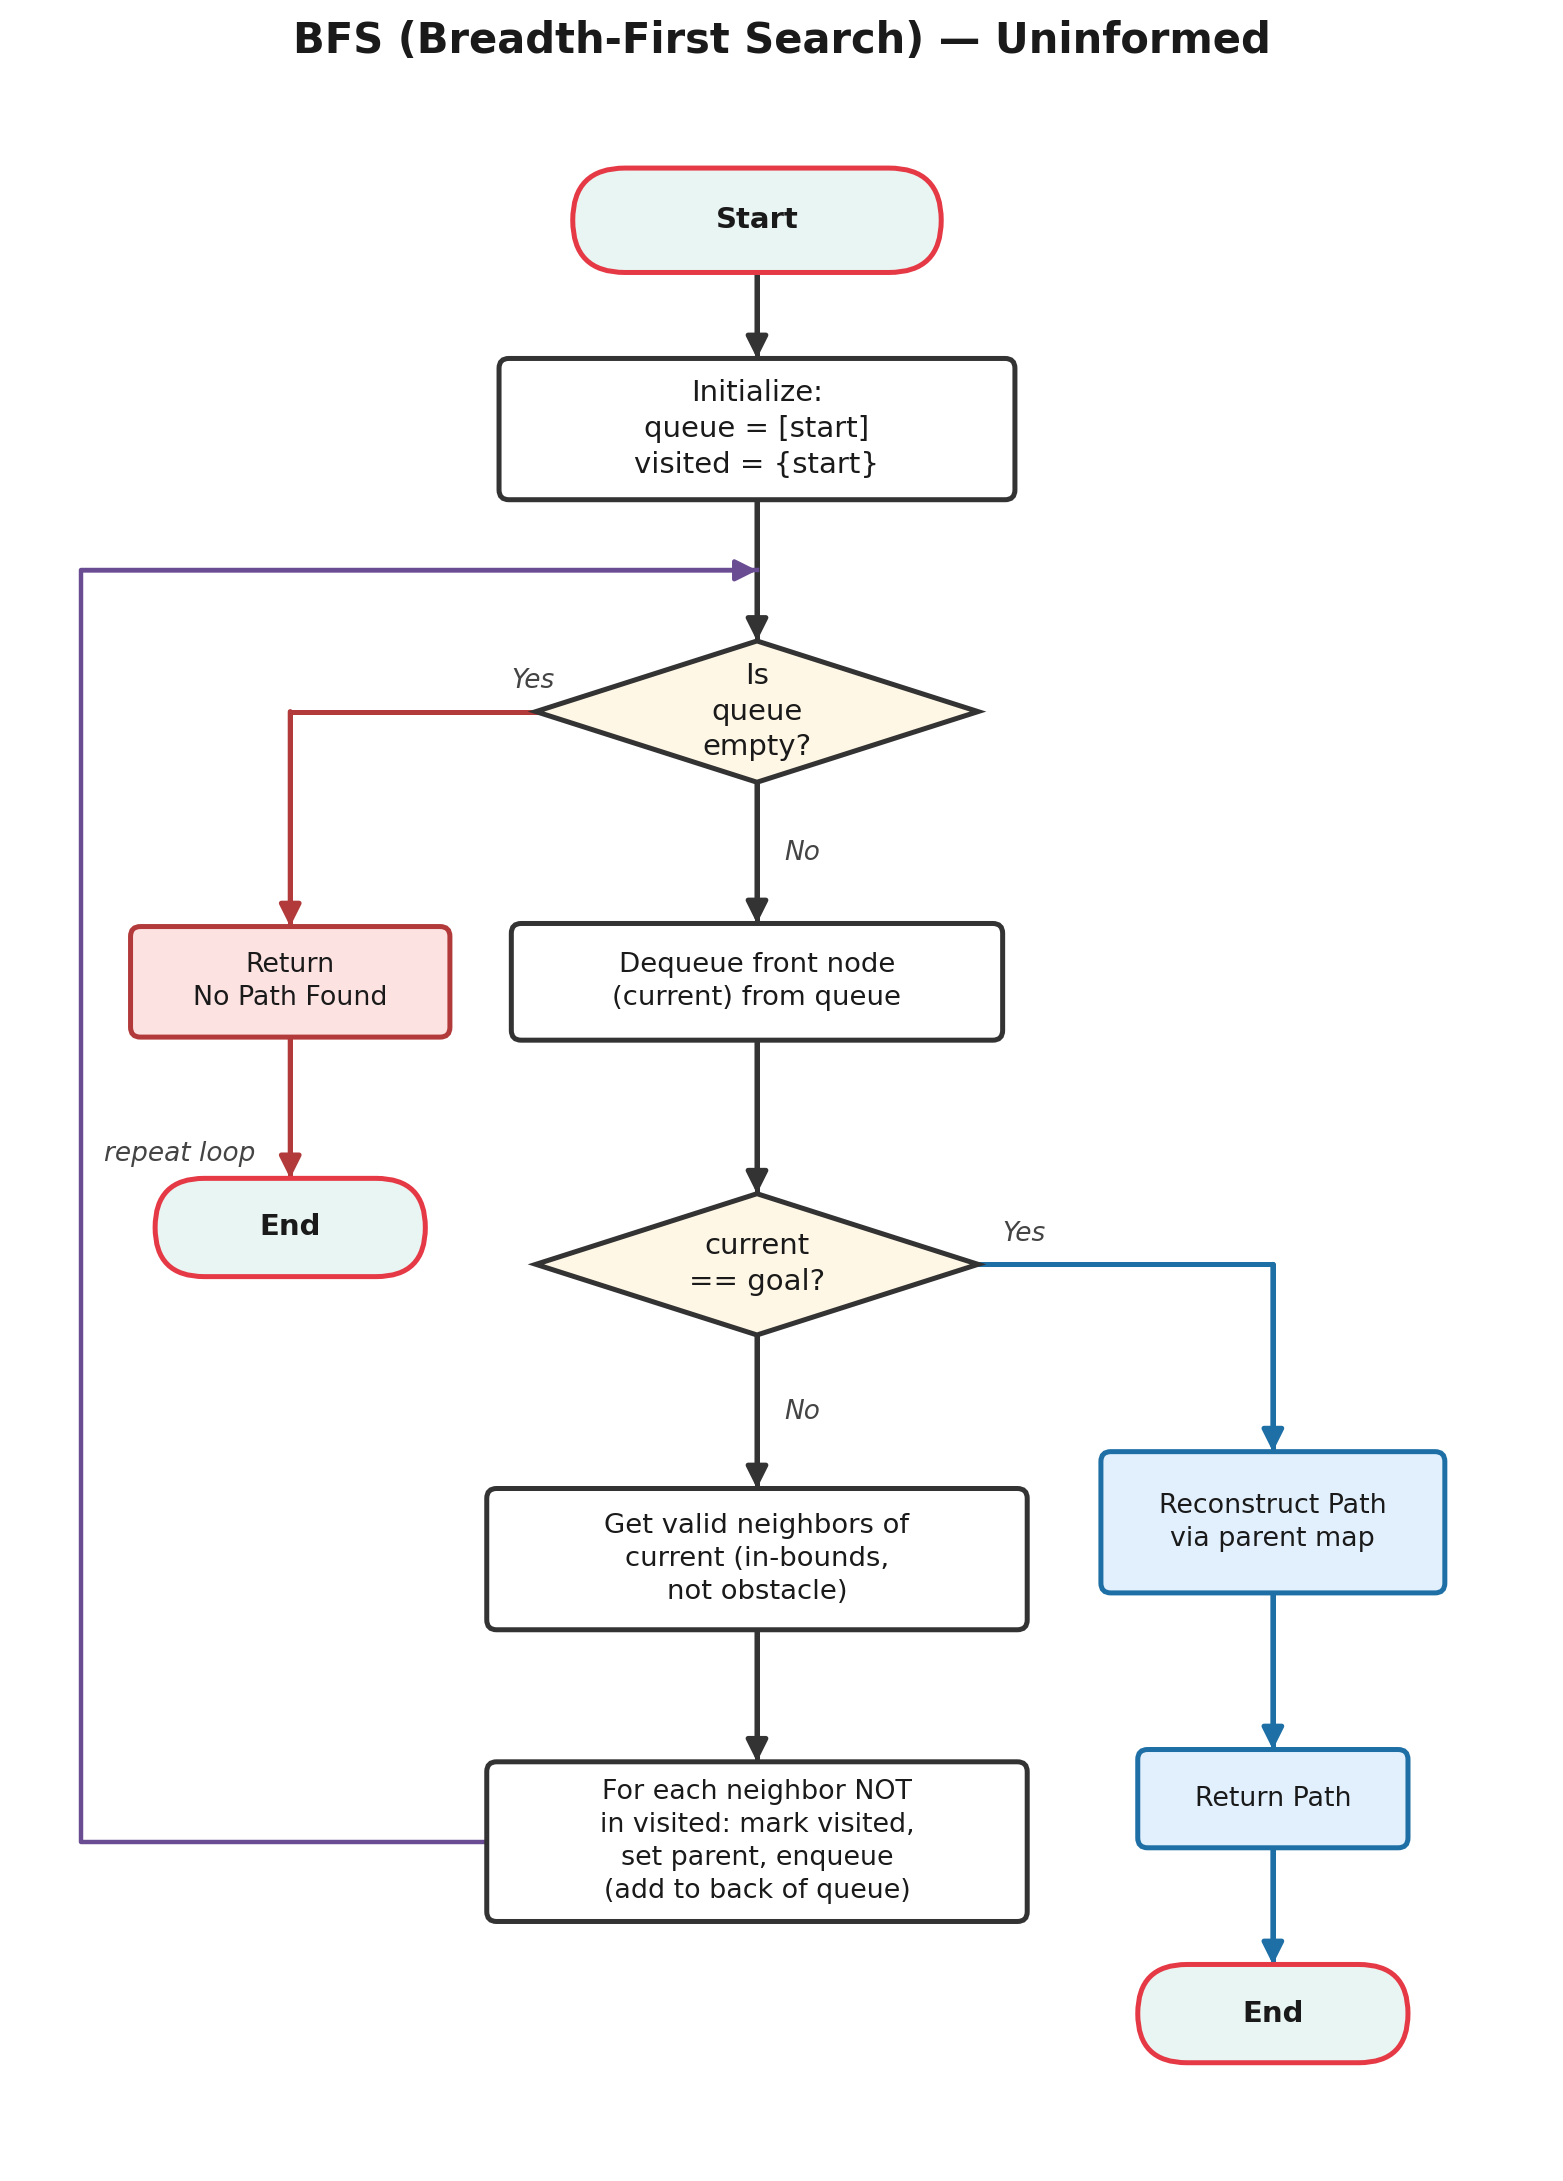

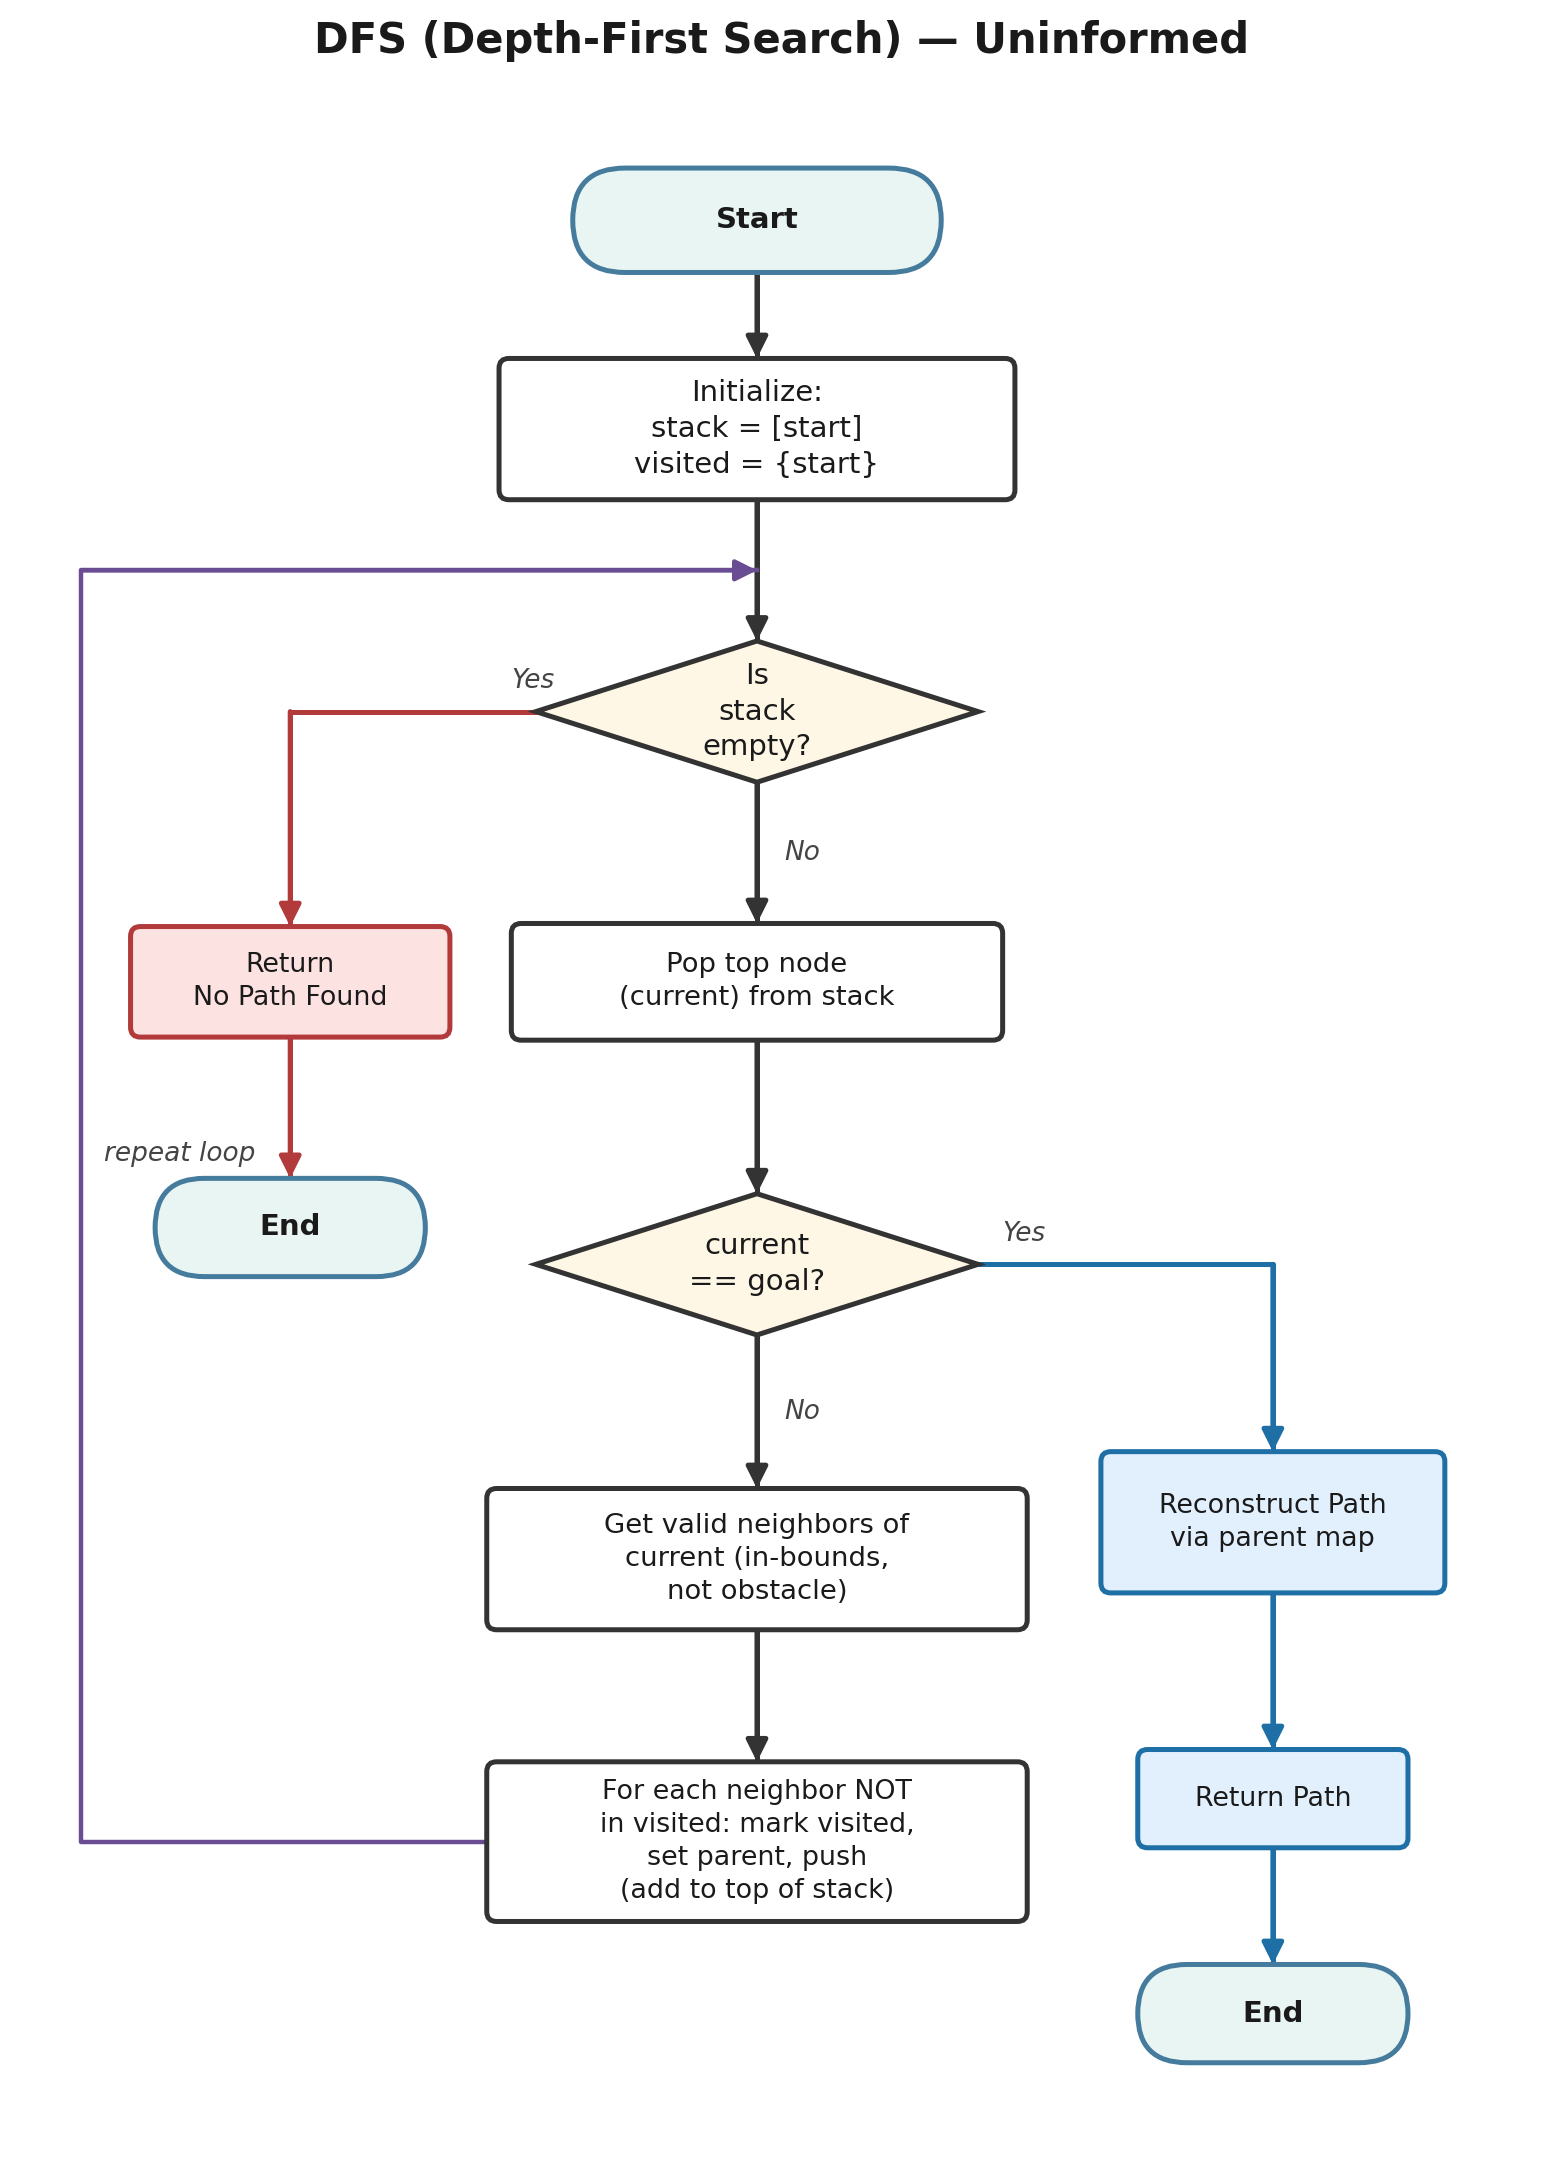

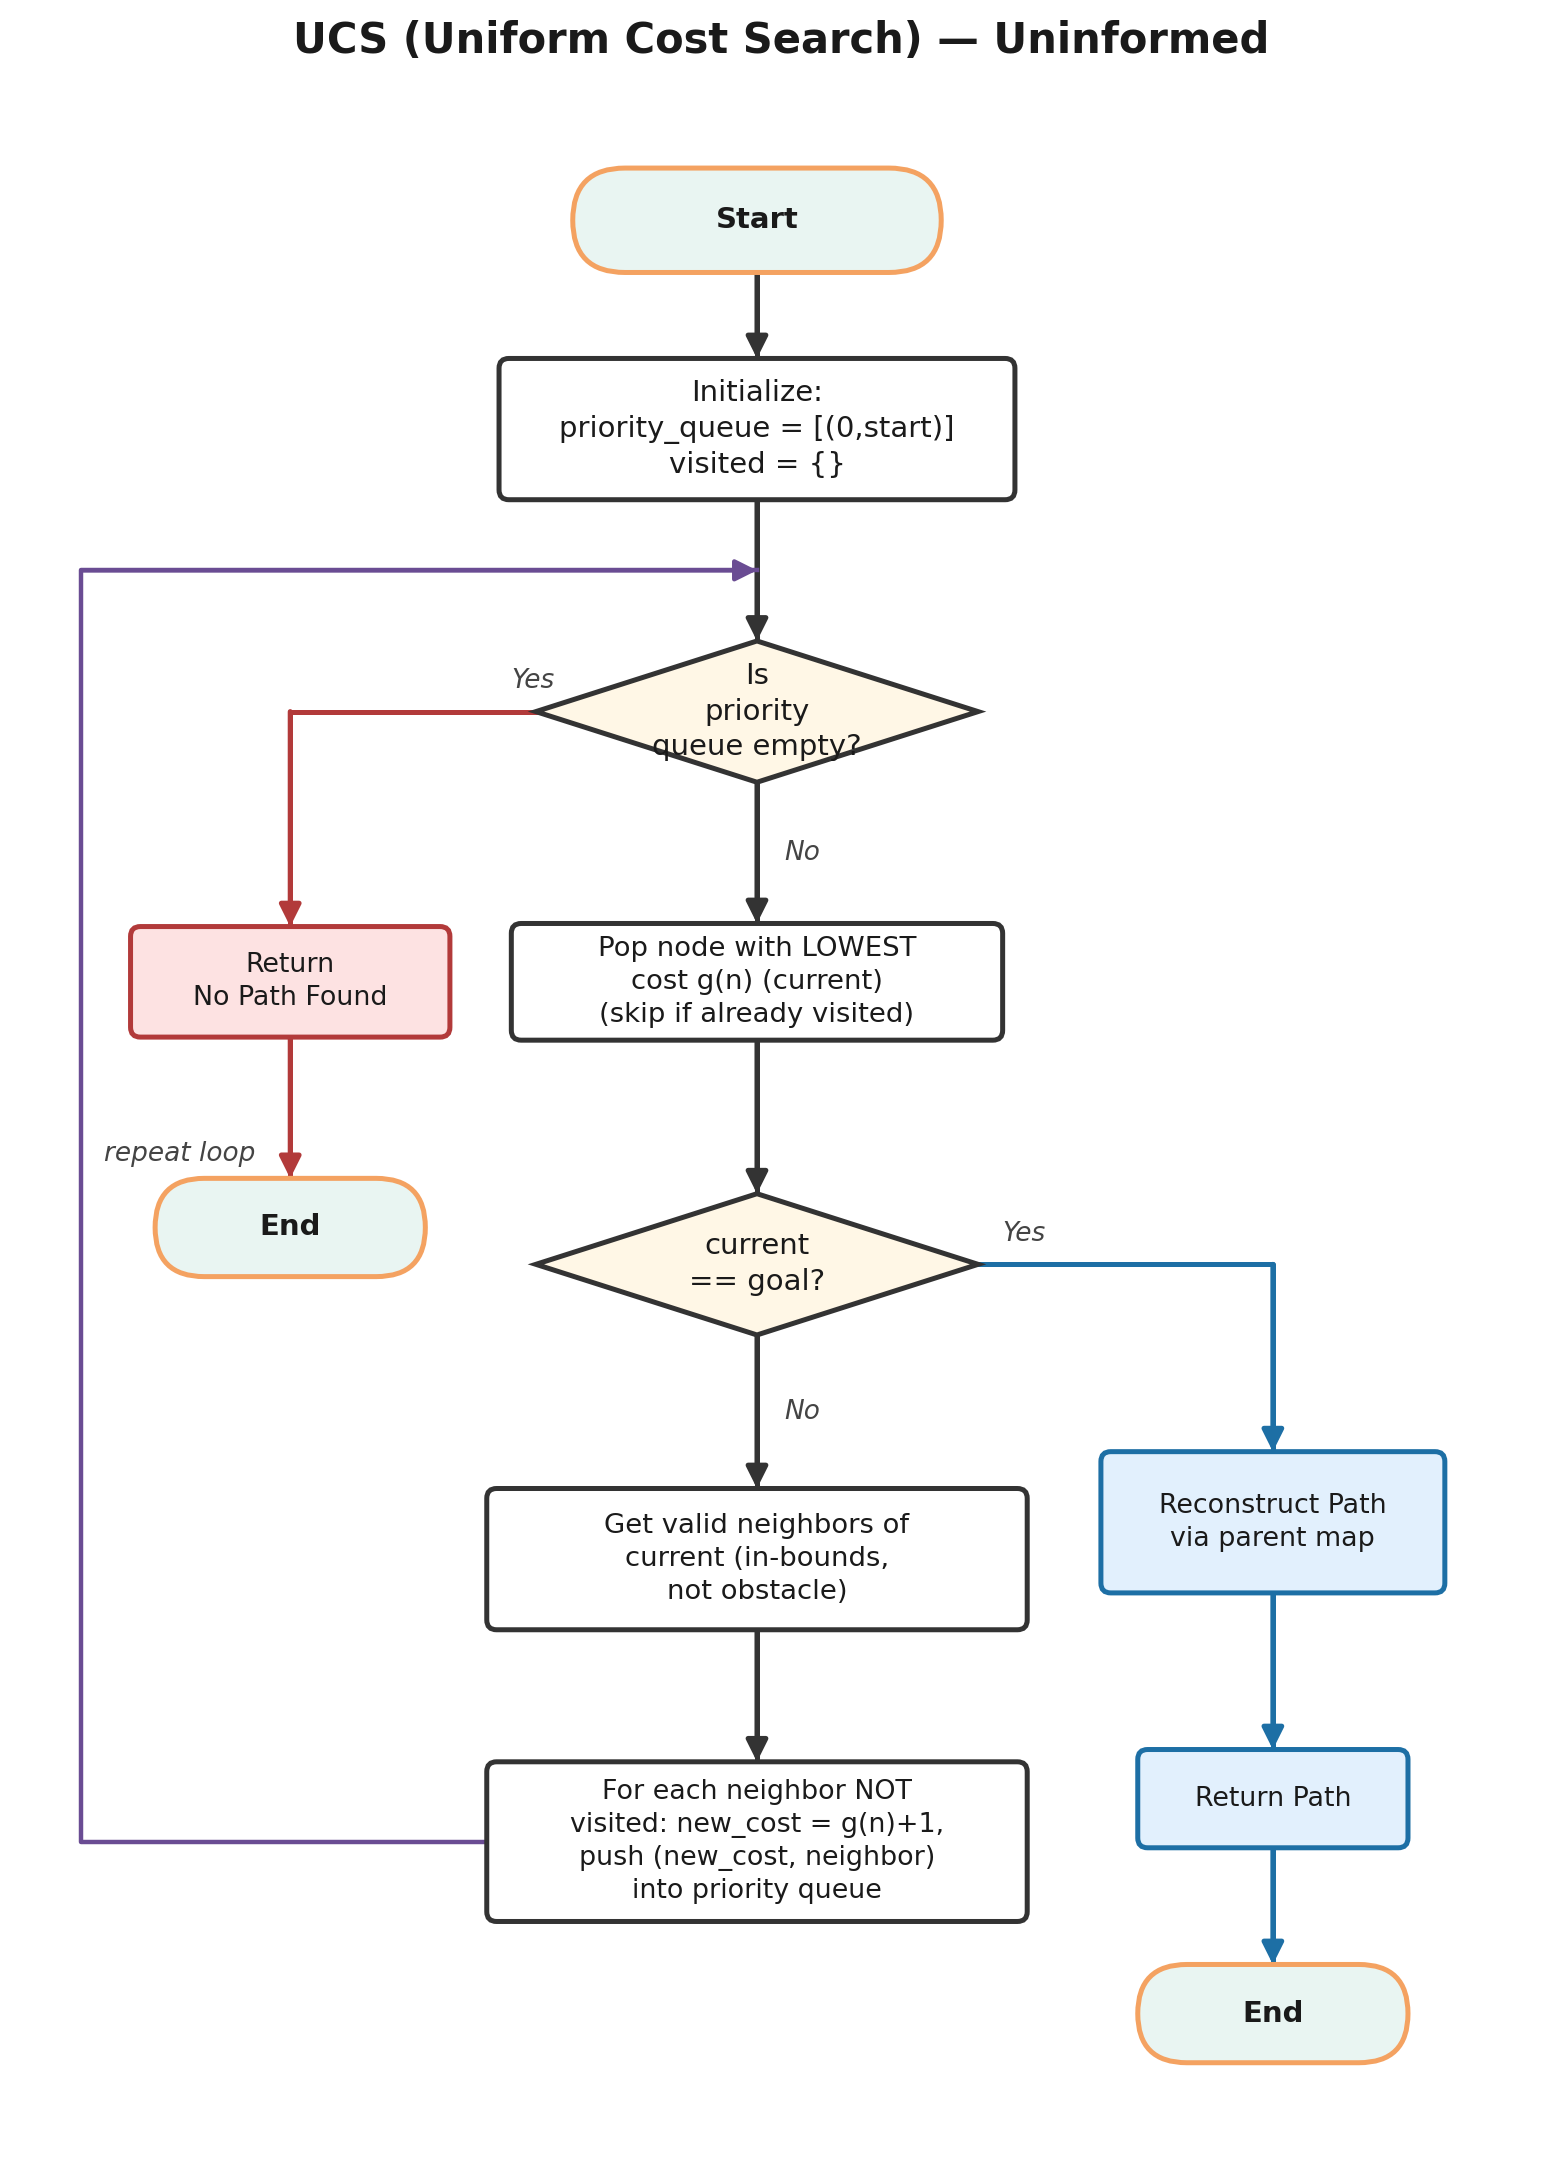

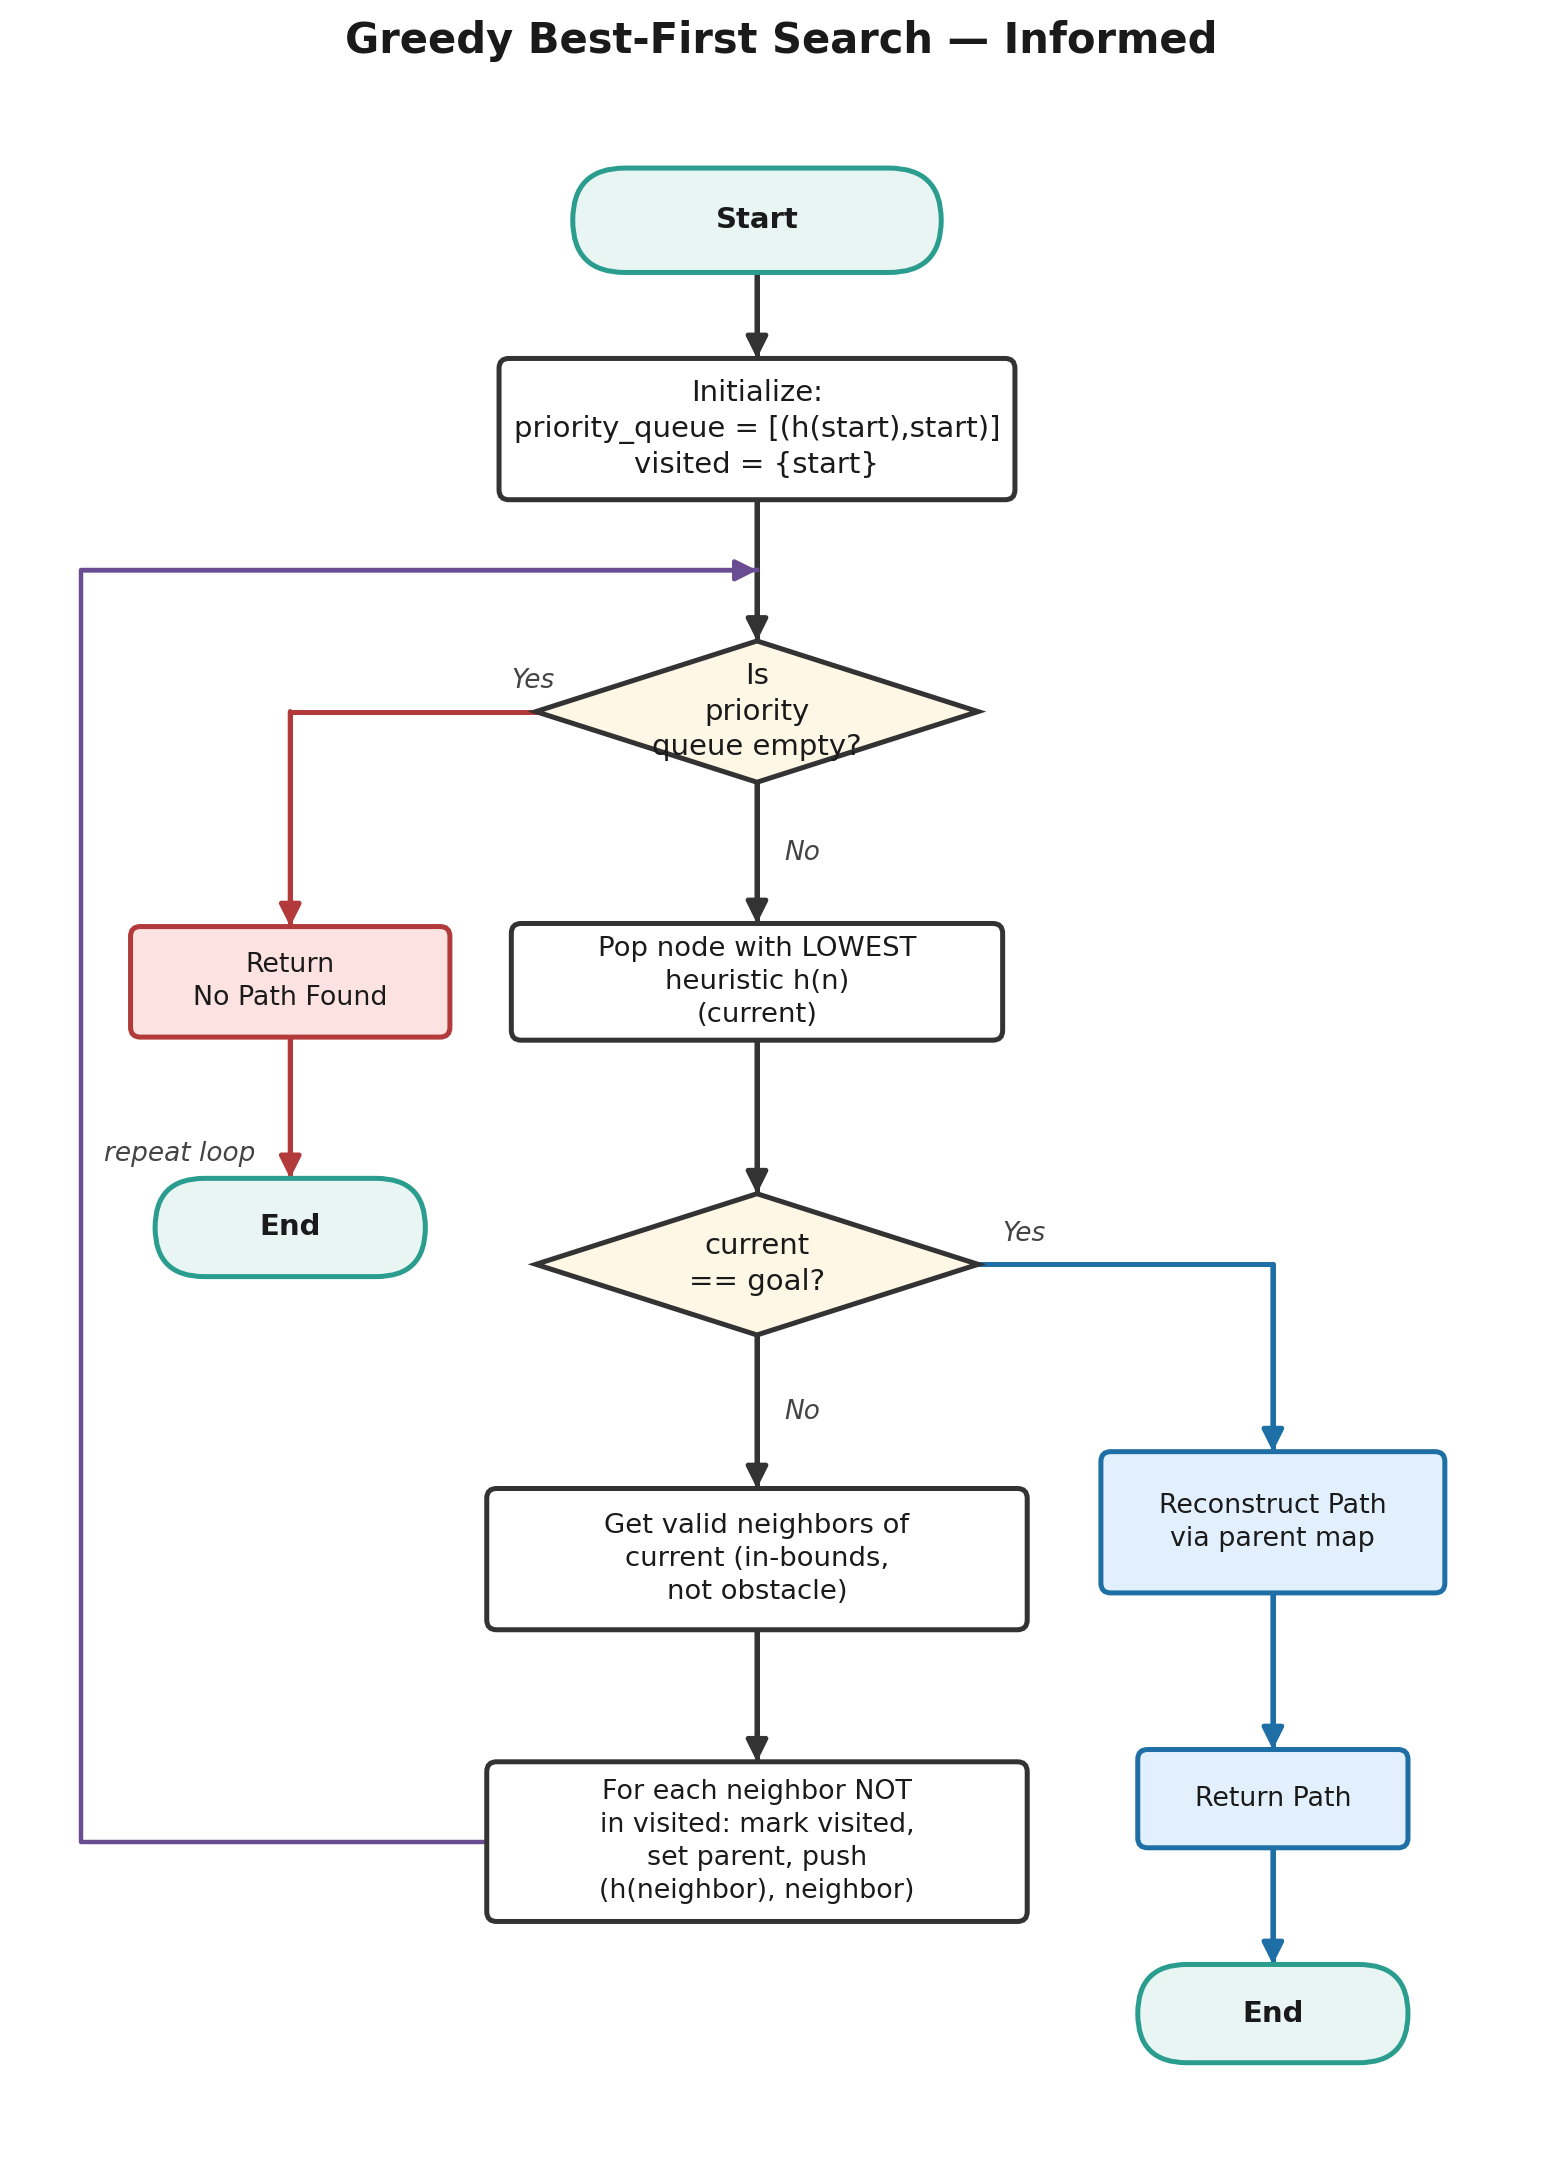

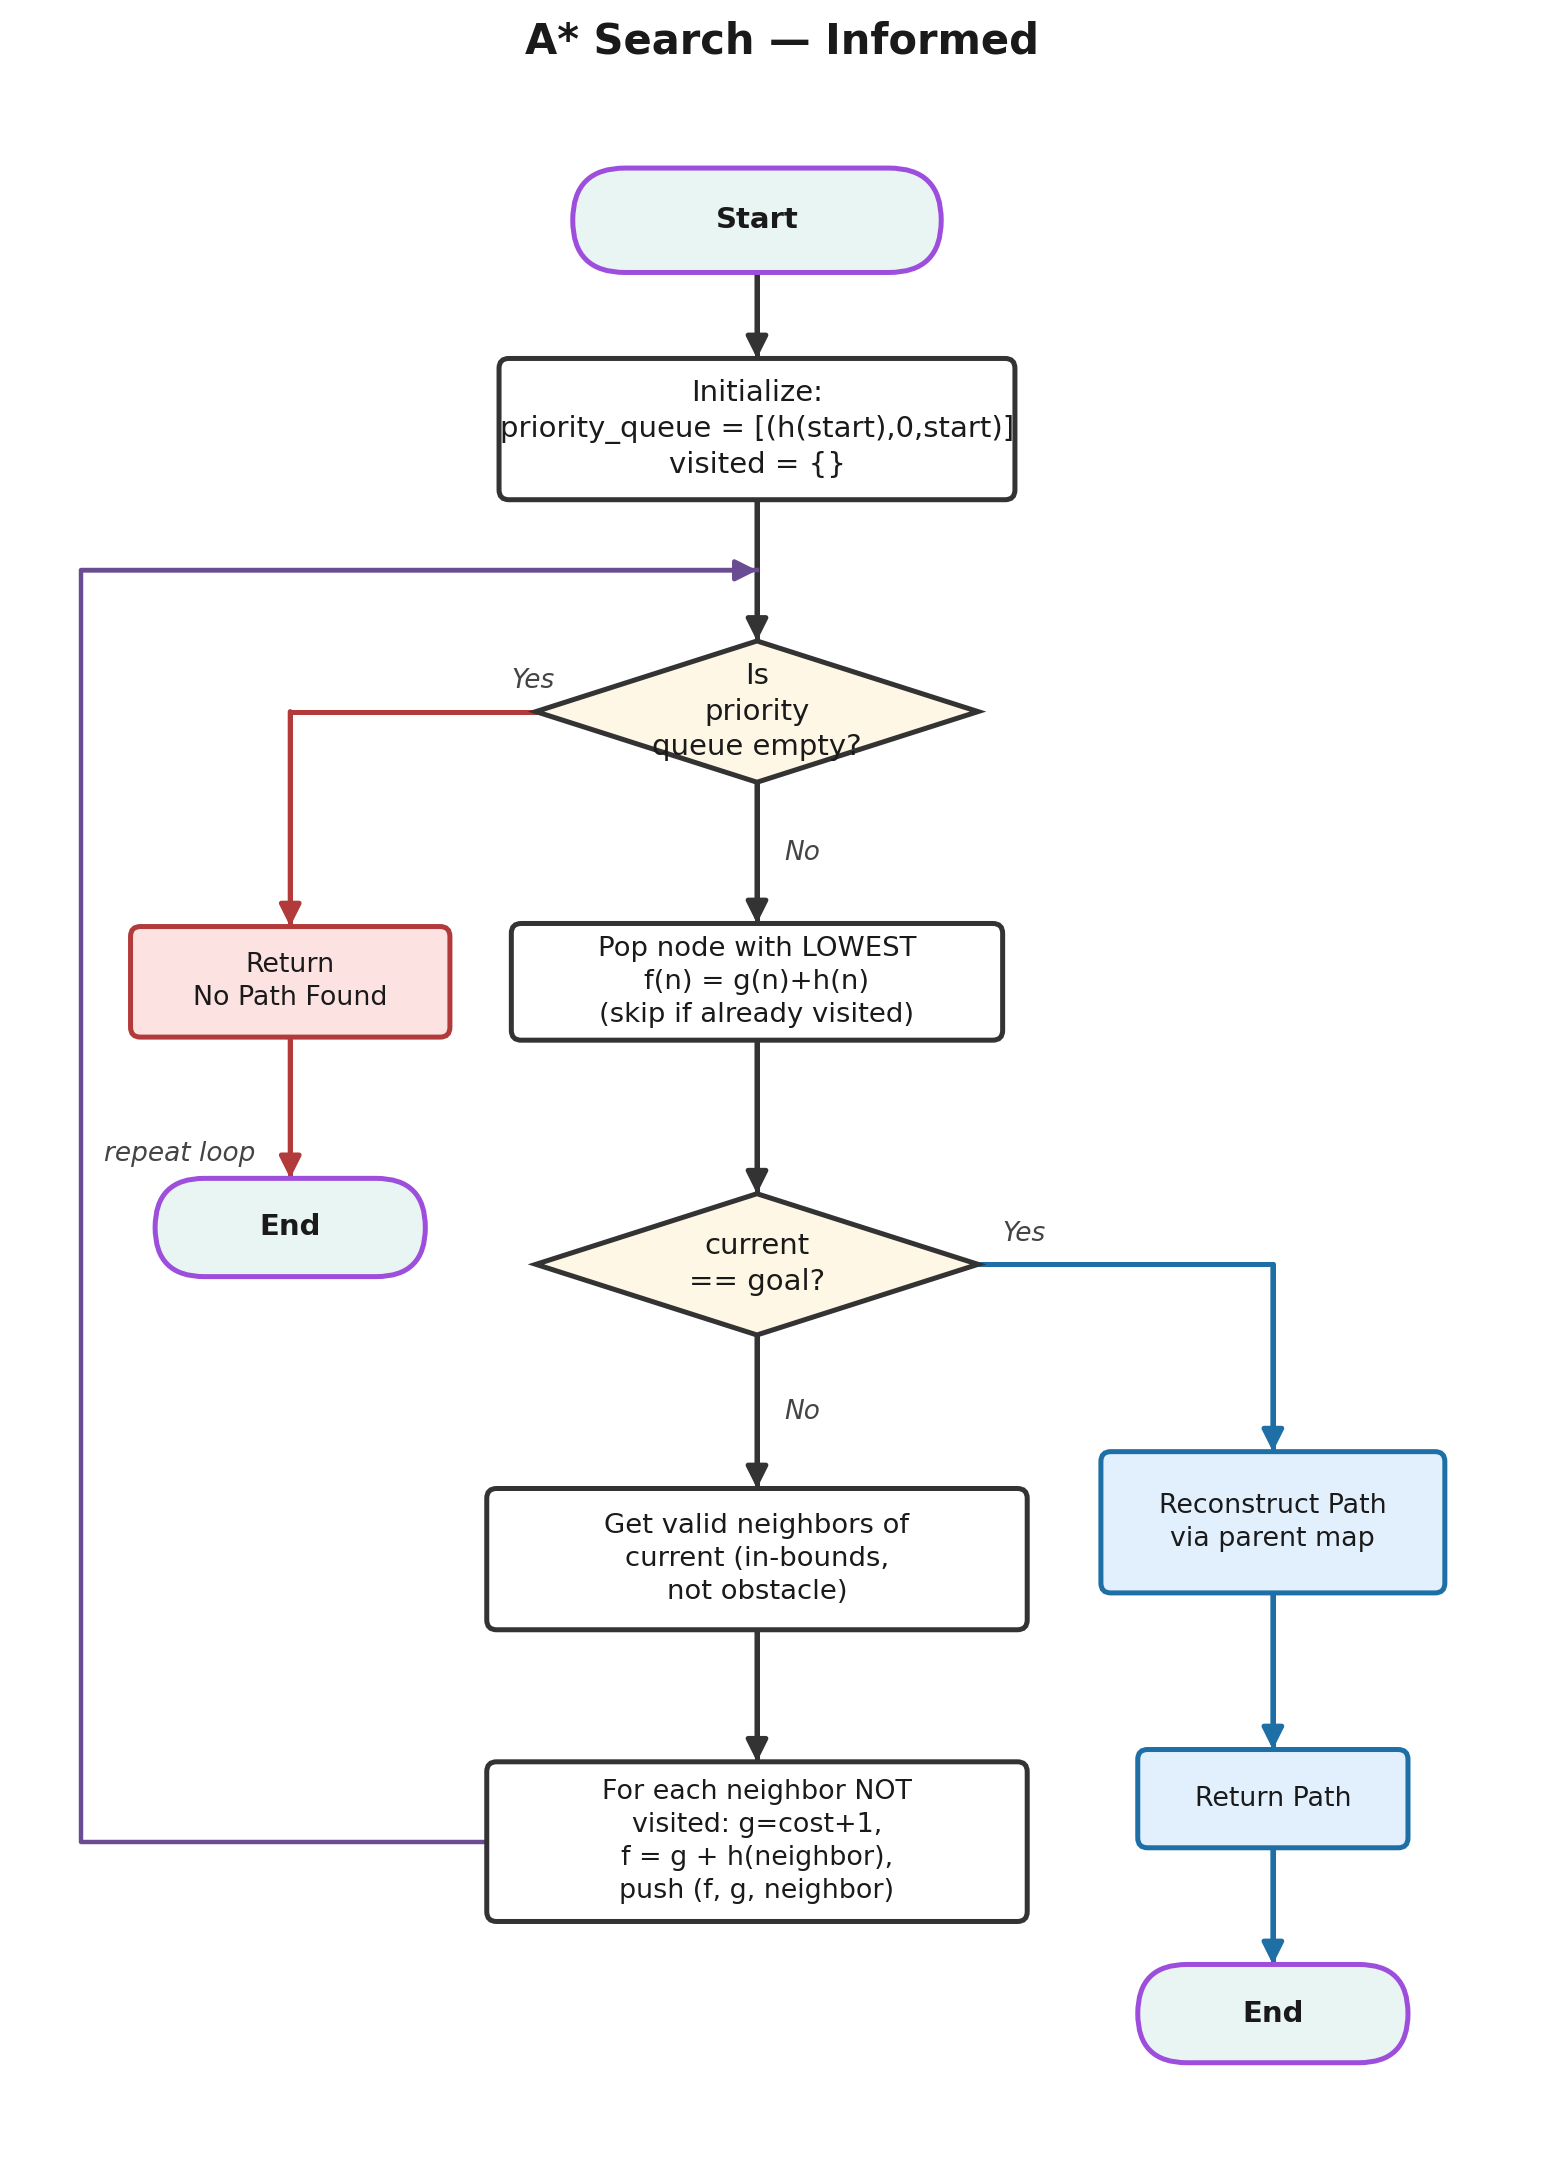

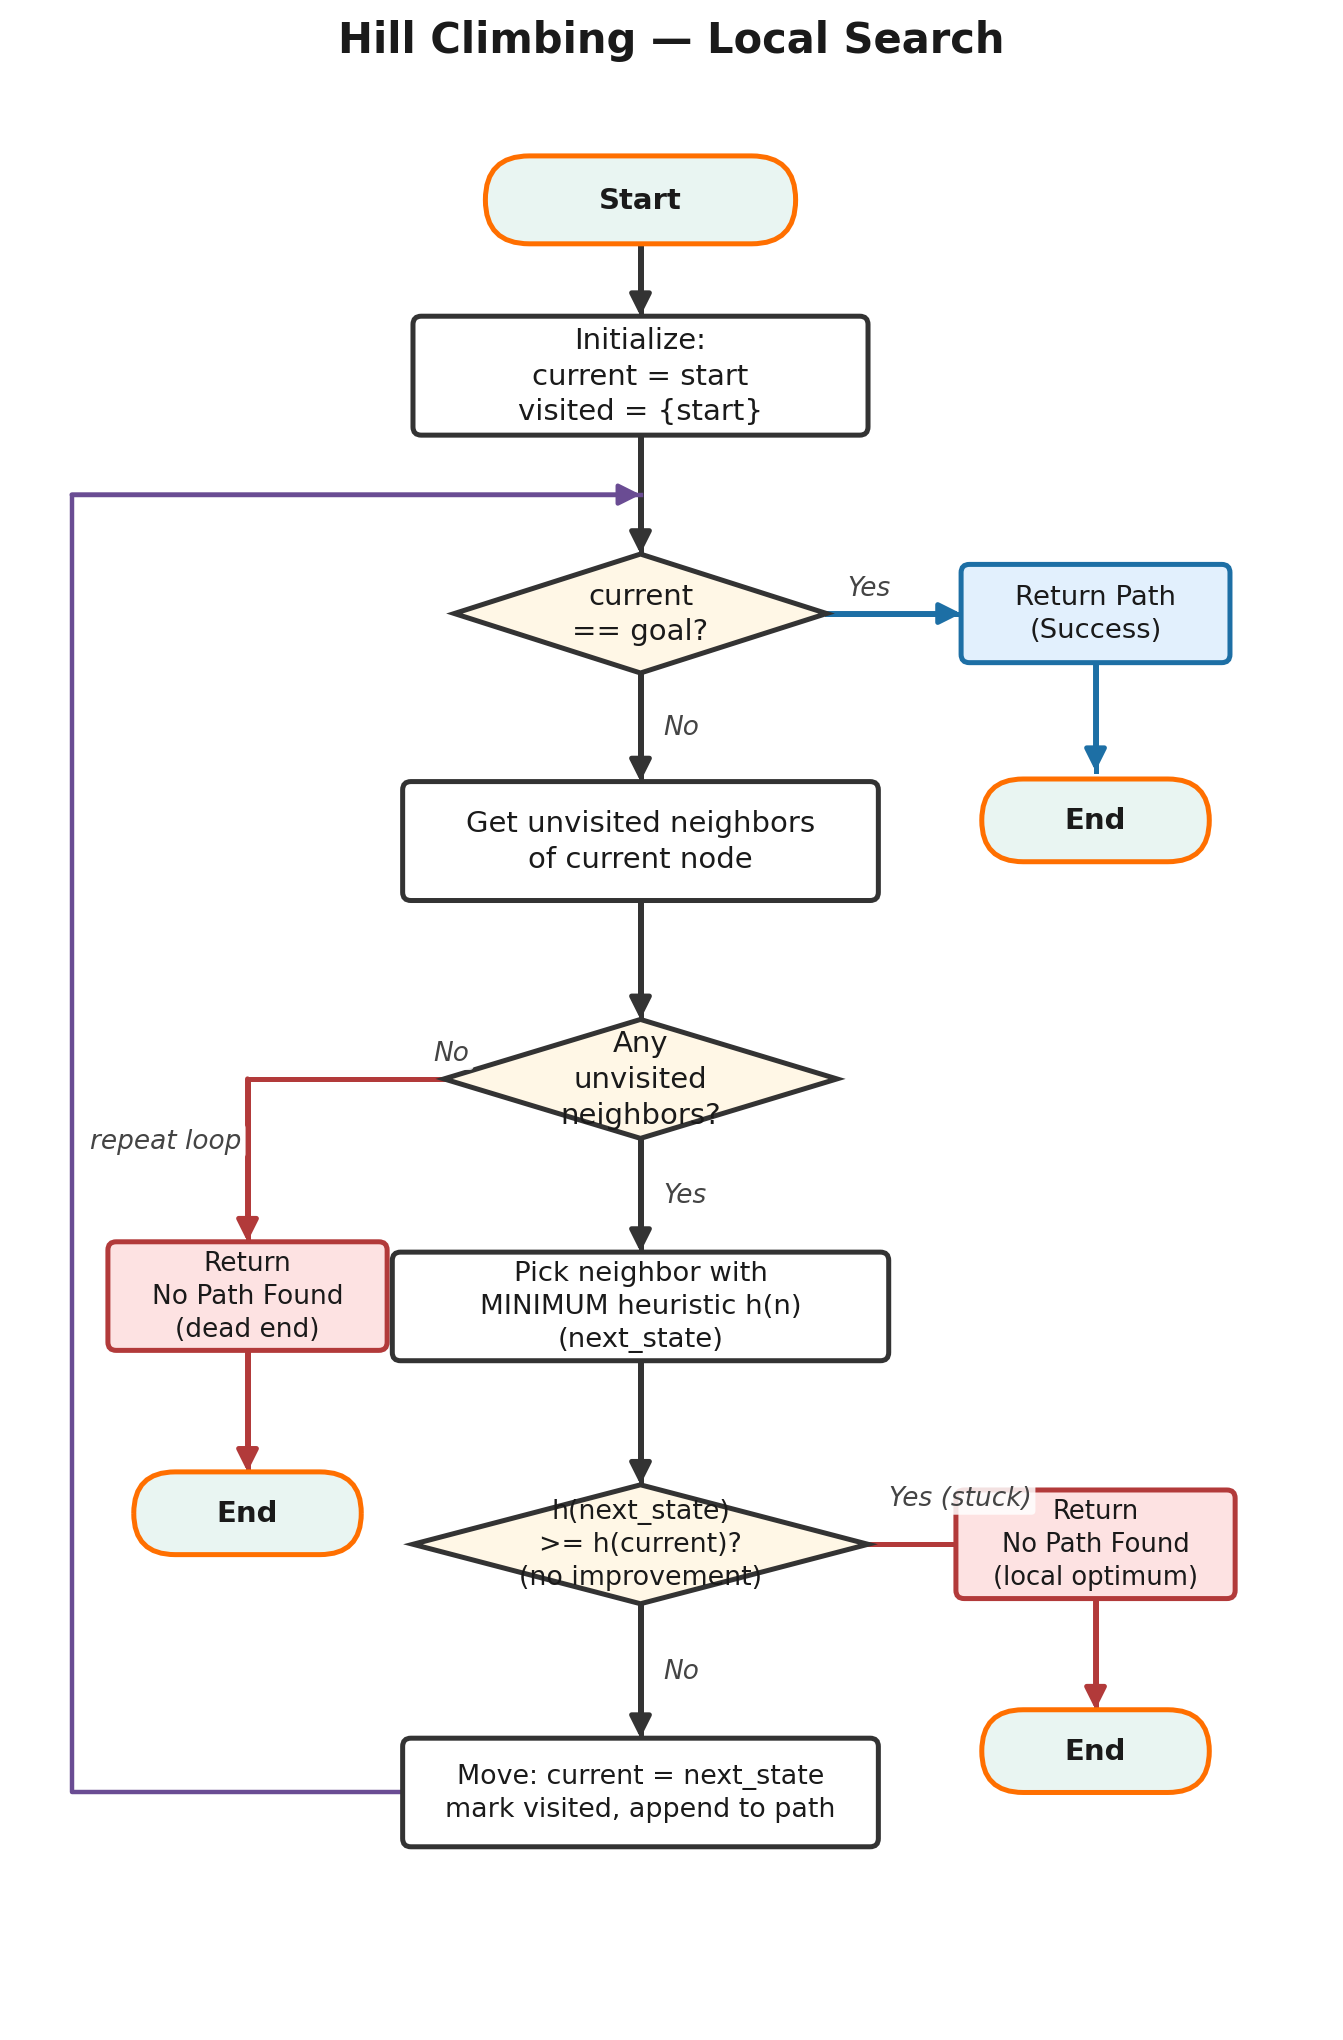

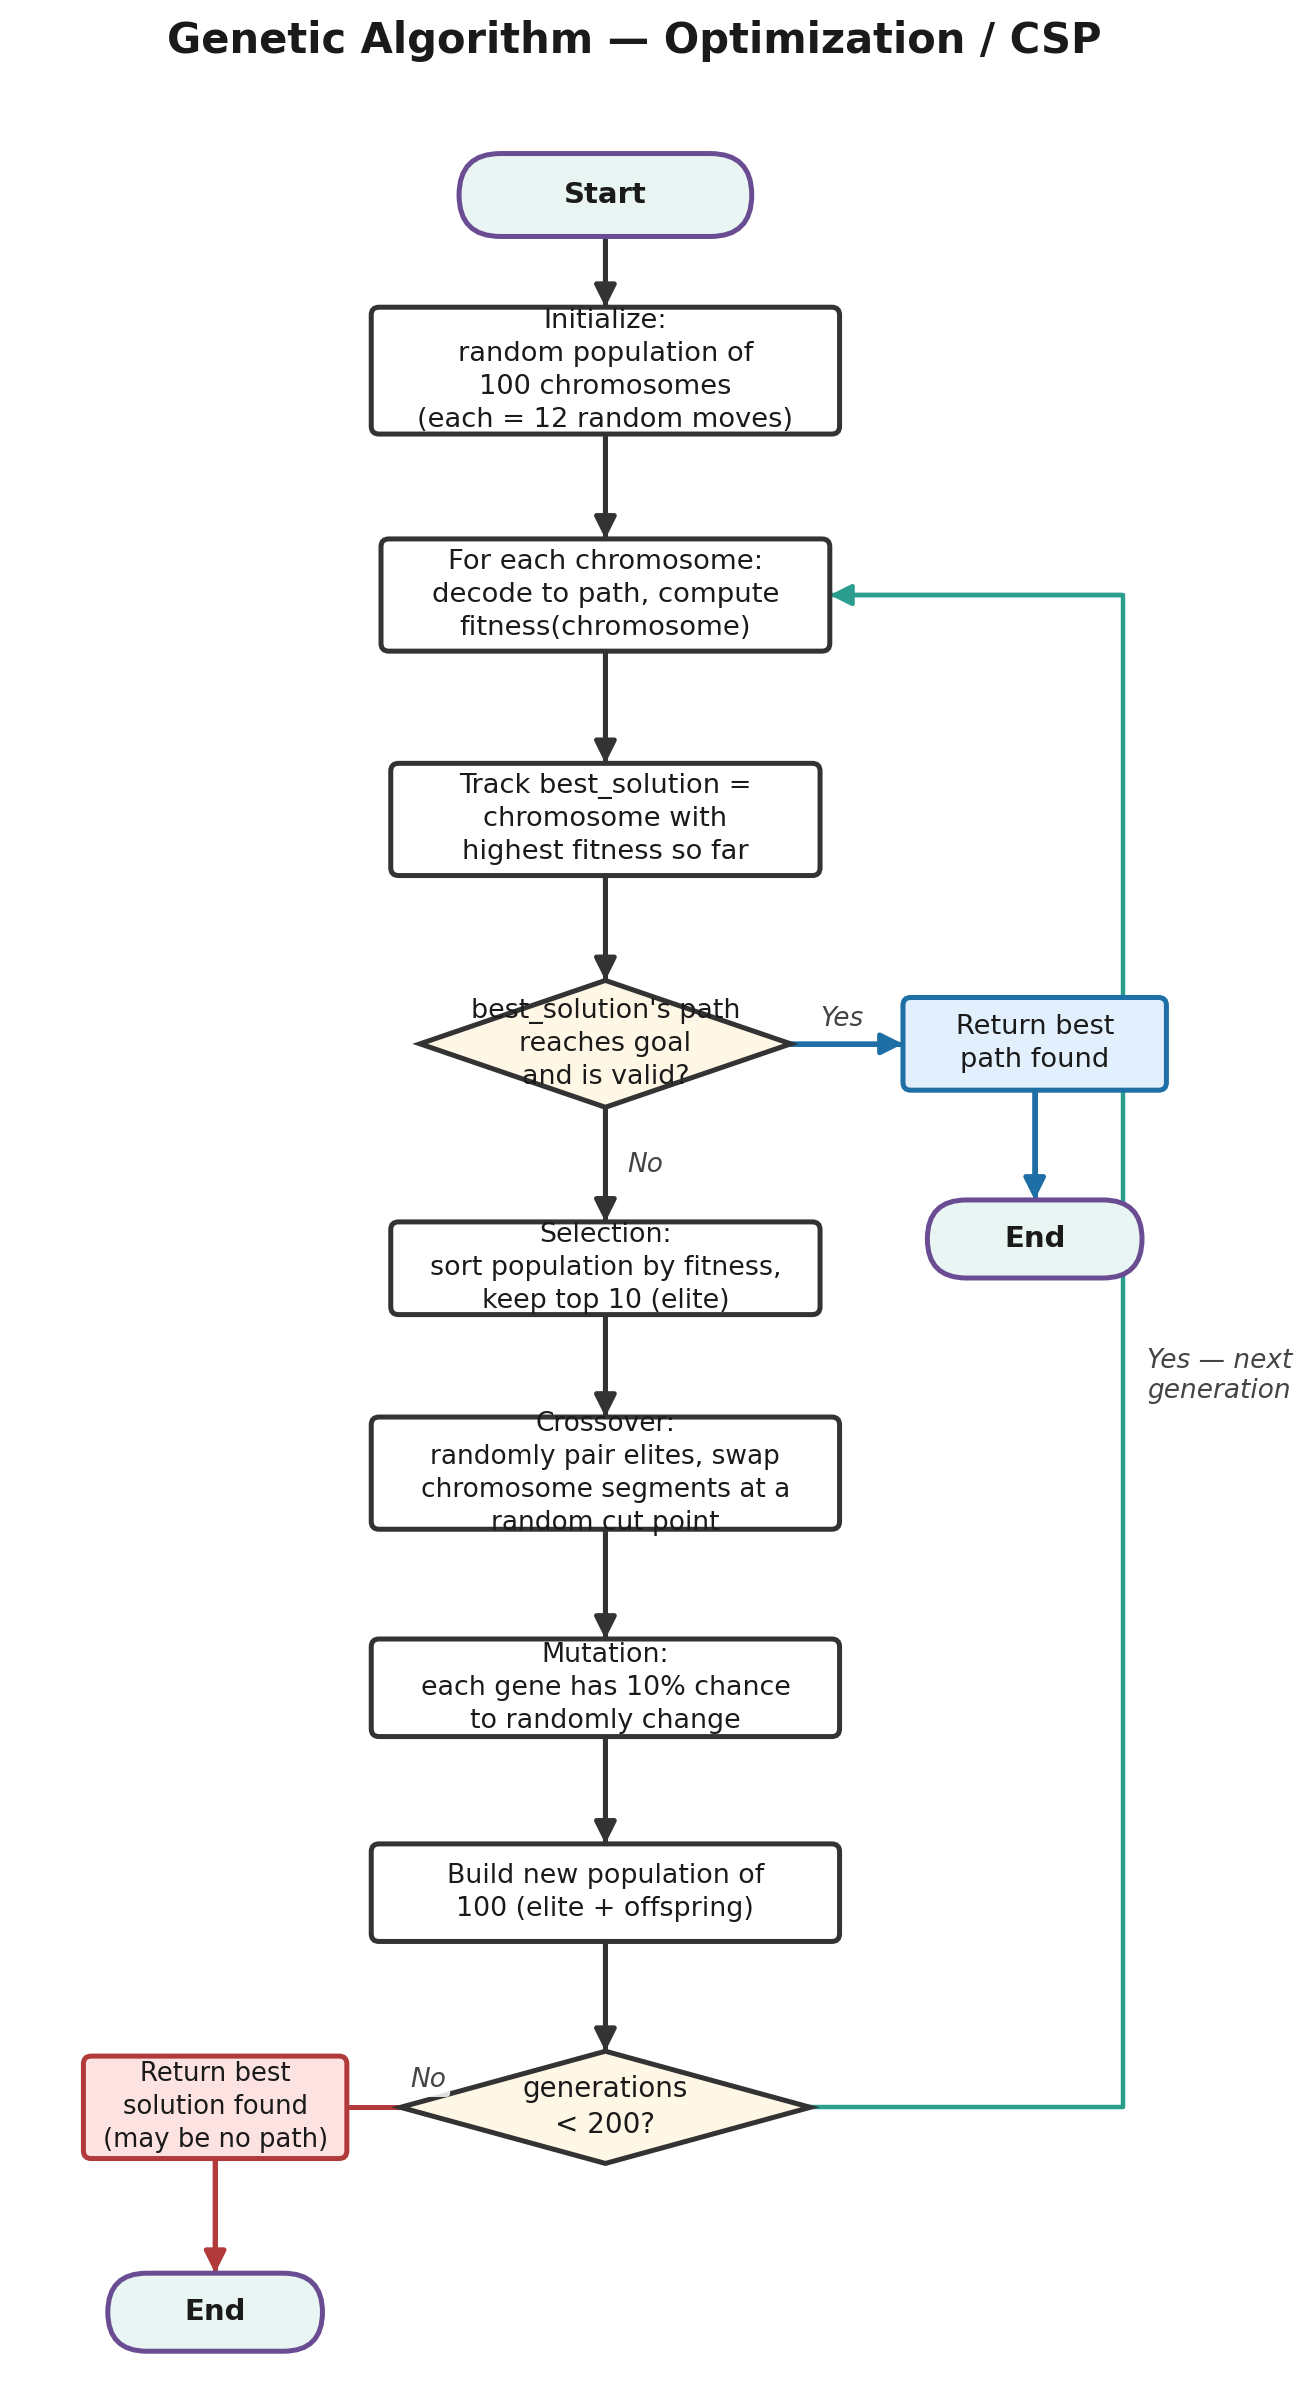



In [1]:
from collections import deque
import heapq
import random
import time

# ============================================================
# ROBOT PATH FINDING USING DIFFERENT SEARCH METHODS
# ============================================================

# 0 = Free Space
# 1 = Obstacle

grid = [
    [0, 0, 0, 1],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 1, 0, 0]
]

# Initial State
start = (0, 0)

# Goal State
goal = (3, 3)

rows = len(grid)
cols = len(grid[0])


# ============================================================
# STATE SPACE
# ============================================================

state_space = []

for row in range(rows):
    for col in range(cols):

        if grid[row][col] == 0:
            state_space.append((row, col))

print("STATE SPACE:")
print(state_space)


# ============================================================
# POSSIBLE MOVEMENTS
# ============================================================

directions = [
    (-1, 0),   # Up
    (1, 0),    # Down
    (0, -1),   # Left
    (0, 1)     # Right
]


# ============================================================
# GET NEXT VALID STATES
# ============================================================

def get_next_states(state):

    next_states = []

    for dr, dc in directions:

        new_row = state[0] + dr
        new_col = state[1] + dc

        next_state = (new_row, new_col)

        if next_state in state_space:
            next_states.append(next_state)

    return next_states


# ============================================================
# CREATE FINAL PATH USING PARENT
# ============================================================

def get_path(parent):

    path = []
    current = goal

    while current != start:

        path.append(current)
        current = parent[current]

    path.append(start)
    path.reverse()

    return path


# ============================================================
# 1. BFS
# UNINFORMED SEARCH
# ============================================================

def bfs():

    queue = deque([start])

    visited = {start}

    parent = {}

    nodes_explored = 0

    while queue:

        current = queue.popleft()

        nodes_explored += 1

        if current == goal:
            return get_path(parent), nodes_explored

        for next_state in get_next_states(current):

            if next_state not in visited:

                visited.add(next_state)

                parent[next_state] = current

                queue.append(next_state)

    return None, nodes_explored


# ============================================================
# 2. DFS
# UNINFORMED SEARCH
# ============================================================

def dfs():

    stack = [start]

    visited = {start}

    parent = {}

    nodes_explored = 0

    while stack:

        current = stack.pop()

        nodes_explored += 1

        if current == goal:
            return get_path(parent), nodes_explored

        for next_state in get_next_states(current):

            if next_state not in visited:

                visited.add(next_state)

                parent[next_state] = current

                stack.append(next_state)

    return None, nodes_explored


# ============================================================
# 3. UCS
# UNINFORMED SEARCH
# ============================================================

def ucs():

    # (cost, state)

    priority_queue = [
        (0, start)
    ]

    visited = set()

    parent = {}

    nodes_explored = 0

    while priority_queue:

        cost, current = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)

        nodes_explored += 1

        if current == goal:
            return get_path(parent), nodes_explored

        for next_state in get_next_states(current):

            if next_state not in visited:

                new_cost = cost + 1

                parent[next_state] = current

                heapq.heappush(
                    priority_queue,
                    (new_cost, next_state)
                )

    return None, nodes_explored


# ============================================================
# HEURISTIC FUNCTION
# MANHATTAN DISTANCE
# ============================================================

def heuristic(state):

    return (
        abs(state[0] - goal[0]) +
        abs(state[1] - goal[1])
    )


# ============================================================
# 4. GREEDY BEST-FIRST SEARCH
# INFORMED SEARCH
# ============================================================

def greedy():

    # (heuristic, state)

    priority_queue = [
        (heuristic(start), start)
    ]

    visited = {start}

    parent = {}

    nodes_explored = 0

    while priority_queue:

        h, current = heapq.heappop(priority_queue)

        nodes_explored += 1

        if current == goal:
            return get_path(parent), nodes_explored

        for next_state in get_next_states(current):

            if next_state not in visited:

                visited.add(next_state)

                parent[next_state] = current

                heapq.heappush(
                    priority_queue,
                    (
                        heuristic(next_state),
                        next_state
                    )
                )

    return None, nodes_explored


# ============================================================
# 5. A* SEARCH
# INFORMED SEARCH
# ============================================================

def a_star():

    # f(n) = g(n) + h(n)

    priority_queue = [
        (heuristic(start), 0, start)
    ]

    visited = set()

    parent = {}

    nodes_explored = 0

    while priority_queue:

        f, cost, current = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)

        nodes_explored += 1

        if current == goal:
            return get_path(parent), nodes_explored

        for next_state in get_next_states(current):

            if next_state not in visited:

                new_cost = cost + 1

                new_f = (
                    new_cost +
                    heuristic(next_state)
                )

                parent[next_state] = current

                heapq.heappush(
                    priority_queue,
                    (
                        new_f,
                        new_cost,
                        next_state
                    )
                )

    return None, nodes_explored


# ============================================================
# 6. HILL CLIMBING
# LOCAL SEARCH
# ============================================================

def hill_climbing():

    current = start

    path = [current]

    visited = {current}

    nodes_explored = 1

    while current != goal:

        neighbors = get_next_states(current)

        # Remove already visited states

        neighbors = [
            state
            for state in neighbors
            if state not in visited
        ]

        if not neighbors:

            return None, nodes_explored

        # Select neighbor with minimum heuristic

        next_state = min(
            neighbors,
            key=heuristic
        )

        # If there is no improvement,
        # Hill Climbing gets stuck.

        if heuristic(next_state) >= heuristic(current):

            return None, nodes_explored

        current = next_state

        visited.add(current)

        path.append(current)

        nodes_explored += 1

    return path, nodes_explored


# ============================================================
# 7. GENETIC ALGORITHM
# CONSTRAINT SATISFACTION / OPTIMIZATION
# ============================================================

# Each chromosome represents a sequence of movements.
#
# 0 = Up
# 1 = Down
# 2 = Left
# 3 = Right

movement_list = [
    (-1, 0),   # Up
    (1, 0),    # Down
    (0, -1),   # Left
    (0, 1)     # Right
]


# ------------------------------------------------------------
# Convert chromosome into a path
# ------------------------------------------------------------

def chromosome_to_path(chromosome):

    current = start

    path = [current]

    valid = True

    for gene in chromosome:

        dr, dc = movement_list[gene]

        new_row = current[0] + dr
        new_col = current[1] + dc

        next_state = (new_row, new_col)

        # Constraint 1:
        # Cannot move outside grid

        if (
            new_row < 0 or
            new_row >= rows or
            new_col < 0 or
            new_col >= cols
        ):

            valid = False
            break

        # Constraint 2:
        # Cannot move through obstacle

        if grid[new_row][new_col] == 1:

            valid = False
            break

        current = next_state

        path.append(current)

    return path, valid


# ------------------------------------------------------------
# FITNESS FUNCTION
# ------------------------------------------------------------

def fitness(chromosome):

    path, valid = chromosome_to_path(chromosome)

    current = path[-1]

    distance = heuristic(current)

    # Goal reached
    if current == goal:

        # Shorter path gets higher fitness
        return 1000 + (100 - len(path))

    # Valid path is better than invalid path

    if valid:

        return 100 - distance * 10 - len(path)

    # Invalid path gets penalty

    return 10 - distance * 20


# ------------------------------------------------------------
# CREATE RANDOM CHROMOSOME
# ------------------------------------------------------------

def create_chromosome(length):

    chromosome = []

    for i in range(length):

        chromosome.append(
            random.randint(0, 3)
        )

    return chromosome


# ------------------------------------------------------------
# CREATE INITIAL POPULATION
# ------------------------------------------------------------

def create_population(size, chromosome_length):

    population = []

    for i in range(size):

        chromosome = create_chromosome(
            chromosome_length
        )

        population.append(chromosome)

    return population


# ------------------------------------------------------------
# SELECTION
# ------------------------------------------------------------

def selection(population):

    population.sort(
        key=fitness,
        reverse=True
    )

    # Keep best individuals

    return population[:10]


# ------------------------------------------------------------
# CROSSOVER
# ------------------------------------------------------------

def crossover(parent1, parent2):

    point = random.randint(
        1,
        len(parent1) - 1
    )

    child1 = (
        parent1[:point] +
        parent2[point:]
    )

    child2 = (
        parent2[:point] +
        parent1[point:]
    )

    return child1, child2


# ------------------------------------------------------------
# MUTATION
# ------------------------------------------------------------

def mutation(chromosome, mutation_rate=0.1):

    for i in range(len(chromosome)):

        if random.random() < mutation_rate:

            chromosome[i] = random.randint(0, 3)

    return chromosome


# ------------------------------------------------------------
# GENETIC ALGORITHM
# ------------------------------------------------------------

def genetic_algorithm():

    # Fixed seed makes experiment reproducible

    random.seed(42)

    population_size = 100

    chromosome_length = 12

    generations = 200

    population = create_population(
        population_size,
        chromosome_length
    )

    nodes_explored = 0

    best_solution = None

    best_fitness = float("-inf")

    for generation in range(generations):

        # Calculate fitness

        for chromosome in population:

            current_fitness = fitness(chromosome)

            nodes_explored += 1

            if current_fitness > best_fitness:

                best_fitness = current_fitness

                best_solution = chromosome[:]

        # Check whether goal is reached

        if best_solution is not None:

            path, valid = chromosome_to_path(
                best_solution
            )

            if (
                path[-1] == goal and
                valid
            ):

                return path, nodes_explored

        # Selection

        selected = selection(
            population
        )

        new_population = []

        # Elitism:
        # Keep the best solution

        new_population.append(
            selected[0][:]
        )

        # Create new population

        while len(new_population) < population_size:

            parent1 = random.choice(selected)

            parent2 = random.choice(selected)

            child1, child2 = crossover(
                parent1,
                parent2
            )

            child1 = mutation(child1)

            child2 = mutation(child2)

            new_population.append(child1)

            if len(new_population) < population_size:

                new_population.append(child2)

        population = new_population

    # Return best solution if goal was found

    if best_solution is not None:

        path, valid = chromosome_to_path(
            best_solution
        )

        if path[-1] == goal and valid:

            return path, nodes_explored

    return None, nodes_explored


# ============================================================
# PERFORMANCE EVALUATION
# ============================================================

def evaluate(name, algorithm):

    start_time = time.perf_counter()

    path, nodes_explored = algorithm()

    end_time = time.perf_counter()

    execution_time = (
        end_time - start_time
    ) * 1000

    if path is not None:

        path_length = len(path) - 1

        print("\n" + "=" * 70)

        print(name)

        print("=" * 70)

        print("Path           :", path)

        print("Path Length    :", path_length)

        print("Nodes Explored :", nodes_explored)

        print(
            "Execution Time :",
            round(execution_time, 6),
            "ms"
        )

        return [
            name,
            path_length,
            nodes_explored,
            round(execution_time, 6)
        ]

    else:

        print("\n" + "=" * 70)

        print(name)

        print("=" * 70)

        print("No path found")

        print(
            "Nodes Explored :",
            nodes_explored
        )

        print(
            "Execution Time :",
            round(execution_time, 6),
            "ms"
        )

        return [
            name,
            "No Path",
            nodes_explored,
            round(execution_time, 6)
        ]


# ============================================================
# RUN ALL ALGORITHMS
# ============================================================

results = []


# ------------------------------------------------------------
# UNINFORMED SEARCH
# ------------------------------------------------------------

results.append(
    evaluate(
        "BFS - Uninformed Search",
        bfs
    )
)

results.append(
    evaluate(
        "DFS - Uninformed Search",
        dfs
    )
)

results.append(
    evaluate(
        "UCS - Uninformed Search",
        ucs
    )
)


# ------------------------------------------------------------
# INFORMED SEARCH
# ------------------------------------------------------------

results.append(
    evaluate(
        "Greedy Best-First - Informed Search",
        greedy
    )
)

results.append(
    evaluate(
        "A* - Informed Search",
        a_star
    )
)


# ------------------------------------------------------------
# LOCAL SEARCH
# ------------------------------------------------------------

results.append(
    evaluate(
        "Hill Climbing - Local Search",
        hill_climbing
    )
)


# ------------------------------------------------------------
# CONSTRAINT SATISFACTION / OPTIMIZATION
# ------------------------------------------------------------

results.append(
    evaluate(
        "Genetic Algorithm - CSP",
        genetic_algorithm
    )
)


# ============================================================
# FINAL PERFORMANCE COMPARISON
# ============================================================

print("\n\n")

print("=" * 90)

print("FINAL PERFORMANCE COMPARISON")

print("=" * 90)

print(
    f"{'Algorithm':<40}"
    f"{'Path Length':<15}"
    f"{'Nodes Explored':<20}"
    f"{'Time (ms)':<15}"
)

print("-" * 90)


for result in results:

    print(
        f"{result[0]:<40}"
        f"{str(result[1]):<15}"
        f"{result[2]:<20}"
        f"{result[3]:<15}"
    )

print("=" * 90)

STATE SPACE:
[(0, 0), (0, 1), (0, 2), (1, 0), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 2), (3, 3)]

BFS - Uninformed Search
Path           : [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3)]
Path Length    : 6
Nodes Explored : 12
Execution Time : 0.059679 ms

DFS - Uninformed Search
Path           : [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]
Path Length    : 6
Nodes Explored : 11
Execution Time : 0.0441 ms

UCS - Uninformed Search
Path           : [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3)]
Path Length    : 6
Nodes Explored : 12
Execution Time : 0.052066 ms

Greedy Best-First - Informed Search
Path           : [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (3, 3)]
Path Length    : 6
Nodes Explored : 8
Execution Time : 0.042732 ms

A* - Informed Search
Path           : [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3)]
Path Length    : 6
Nodes Explored : 12
Execution Time : 0.06627 ms

Hill Climbing - Local Search
No path found
Nodes 

result:

Algorithms that successfully found a path:

BFS, DFS, UCS, Greedy Best-First, and A* all managed to find a path from the start (0,0) to the goal (3,3). Each of these paths was 6 steps long.

When it came to how many nodes they checked:
Greedy Best-First was quite efficient, looking at only 8 nodes. This was probably because it used a good guess (heuristic) to guide its way.
DFS checked 11 nodes, which was a bit fewer than BFS, UCS, and A*.
BFS, UCS, and A* each explored 12 nodes.

Their execution times were very fast for this small grid, generally ranging from about 0.04 ms to 0.06 ms.

Algorithms that did not find a path:

Hill Climbing - Local Search didn't find a path. It only explored 4 nodes before getting stuck. This often happens with Hill Climbing; it can get caught in a local optimum, where it can't find a better move even if a global best solution exists elsewhere.

The Genetic Algorithm - CSP also couldn't find a path. It explored a lot more nodes (20,000) and took much longer (180.38 ms) than the other algorithms. It seems it couldn't come up with a valid path for this specific problem within the limits we set for generations and chromosome parameters. Genetic Algorithms often need a lot of tweaking (like adjusting population size or mutation rates) and don't always promise a solution, especially when path rules are strict or the search area is complicated.

Conclusion:

For this specific grid and problem, the algorithms that used some form of guidance (Greedy Best-First and A*) and even the simpler ones (BFS, DFS, UCS) were good at finding a path. Greedy Best-First was notably efficient in terms of how much it had to explore. However, local search (Hill Climbing) and optimization (Genetic Algorithm) methods had trouble, with Hill Climbing getting stuck and the Genetic Algorithm not quite making it to a solution with our current settings.

Outcomes:

We successfully put into practice and compared different search algorithms for a robot trying to find its way in a grid. Here are the main things we found:

Uninformed Search (BFS, DFS, UCS): All three of these algorithms successfully found a path that was 6 steps long. BFS and UCS each explored 12 nodes, while DFS was a bit more efficient for this particular problem, exploring 11 nodes. They all ran very quickly, taking only about 0.04-0.06 milliseconds.

Informed Search (Greedy Best-First, A*): Both of these algorithms, which use extra information to guide their search, also found optimal paths of 6 steps. Greedy Best-First was the most efficient in terms of how many nodes it checked, at just 8 nodes, showing how helpful a good heuristic can be. A* explored 12 nodes, similar to BFS/UCS, but it also guarantees finding the best possible path.

Local Search (Hill Climbing): The original Hill Climbing algorithm couldn't find a path; it got stuck in a local optimum after looking at only 4 nodes. We made an improved version that tries to take a random step if it can't find an immediate better move, which should help it escape these local traps in some situations, though it still doesn't guarantee a path every time.

Constraint Satisfaction/Optimization (Genetic Algorithm): The Genetic Algorithm explored a lot of nodes (20,000) and took the longest to run (180.38 ms), but it still didn't find a valid path in this case. This shows that Genetic Algorithms often need a lot of fine-tuning of their parameters and might not always be the best choice for simple pathfinding problems where more direct search methods work well.

Final Thoughts: For finding paths in a small, unchanging grid with clear starting and ending points, informed search algorithms like Greedy Best-First and A* (and even the simpler BFS/UCS) are very effective and dependable. Local search methods like Hill Climbing really benefit from strategies that help them avoid getting stuck in local optima. Genetic Algorithms are powerful for optimization, but for problems that are straightforward for other search methods, they can sometimes be overly complex and require careful setup.

githublink: